<a href="https://colab.research.google.com/github/Riz2693/Higo-Technical-Test/blob/main/2.%20Analisis%20Dan%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library Yang Digunakan**

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import iqr

In [232]:
# Mengatur tema visualisasi agar lebih menarik
sns.set_theme(style="whitegrid")

# **Load dataset**

In [233]:
df = pd.read_csv('https://raw.githubusercontent.com/Riz2693/Higo-Technical-Test/refs/heads/main/data_dummy_pengguna.csv')
df.head(5)

,Nama Lokasi,Tipe Lokasi,Jam Login,Nama,Email,No Telepon,Tahun Lahir,Merk HP,Minat Digital,CTR,Durasi Akses (Menit/Minggu),Skor CTR,Skor Durasi Akses (Menit/Minggu),Skor Minat Digital,Level Respons CTR,Level Durasi Akses,Level Minat Digital,Usia,Sesi Login
0,Kopi Kenangan Senayan,Cafe,00:47:17,"Balidin Dongoran, S.T.",ivanmandala@hotmail.com,+62 (081) 960-0133,1987,Apple,F&B & Culinary Lifestyle,11.0,149,73.333333,24.833333,49.1,Tinggi,Rendah,Sedang,39,Malam
1,Stasiun Sudirman,Transportasi,13:02:01,Drs. Akarsana Purwanti,salsabilapalastri@yahoo.com,+62-0794-026-5423,1982,Apple,F&B & Culinary Lifestyle,7.6,87,50.666667,14.500000,32.6,Sedang,Rendah,Rendah,44,Siang
2,Stasiun Sudirman,Transportasi,06:45:41,"Tgk. Baktiono Iswahyudi, S.Sos",tambamalik@hotmail.com,+62 (0078) 161 8495,2002,Vivo,Entertainment & Streaming,3.3,344,22.000000,57.333333,39.7,Rendah,Sedang,Rendah,24,Pagi
3,Kopi Kenangan Senayan,Cafe,05:44:27,R.A. Tiara Hidayat,wijayantijaga@yahoo.com,+62 (031) 647 5255,1990,Xiaomi,F&B & Culinary Lifestyle,3.2,404,21.333333,67.333333,44.3,Rendah,Sedang,Sedang,36,Pagi
4,Kopi Kenangan Senayan,Cafe,02:24:06,Mumpuni Santoso,sudiatirahmi@gmail.com,0832764835,1991,Xiaomi,Travel & Leisure,4.0,104,26.666667,17.333333,22.0,Rendah,Rendah,Rendah,35,Malam


# **Cek Informasi Dataset**

In [234]:
# Cek type data dan jumlah kolom pada dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Nama Lokasi                       1000 non-null   object 
 1   Tipe Lokasi                       1000 non-null   object 
 2   Jam Login                         1000 non-null   object 
 3   Nama                              1000 non-null   object 
 4   Email                             1000 non-null   object 
 5   No Telepon                        1000 non-null   object 
 6   Tahun Lahir                       1000 non-null   int64  
 7   Merk HP                           1000 non-null   object 
 8   Minat Digital                     1000 non-null   object 
 9   CTR                               1000 non-null   float64
 10  Durasi Akses (Menit/Minggu)       1000 non-null   int64  
 11  Skor CTR                          1000 non-null   float64
 12  Skor Du

In [235]:
# Cek informasi numerik pada dataset
df.describe()

,Tahun Lahir,CTR,Durasi Akses (Menit/Minggu),Skor CTR,Skor Durasi Akses (Menit/Minggu),Skor Minat Digital,Usia
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1994.490000,7.344600,335.182000,48.964000,55.863667,52.413500,31.510000
std,8.466025,4.286949,154.665459,28.579658,25.777577,19.169935,8.466025
min,1980.000000,0.000000,62.000000,0.000000,10.333333,6.500000,18.000000
25%,1987.000000,3.600000,198.000000,24.000000,33.000000,38.450000,24.000000
50%,1995.000000,7.300000,340.000000,48.666667,56.666667,52.100000,31.000000
75%,2002.000000,10.800000,470.750000,72.000000,78.458333,65.450000,39.000000
max,2008.000000,15.000000,599.000000,100.000000,99.833333,99.300000,46.000000


# **Drop beberapa kolom yang tidak digunakan untuk mempermudah EDA**

In [236]:
# Drop kolom jam login dan tahun lahir karena sudah terdapat kolom hasil ekstraksi nya
df.drop(['Jam Login', 'Tahun Lahir'], inplace=True, axis=1)
df.head(5)

,Nama Lokasi,Tipe Lokasi,Nama,Email,No Telepon,Merk HP,Minat Digital,CTR,Durasi Akses (Menit/Minggu),Skor CTR,Skor Durasi Akses (Menit/Minggu),Skor Minat Digital,Level Respons CTR,Level Durasi Akses,Level Minat Digital,Usia,Sesi Login
0,Kopi Kenangan Senayan,Cafe,"Balidin Dongoran, S.T.",ivanmandala@hotmail.com,+62 (081) 960-0133,Apple,F&B & Culinary Lifestyle,11.0,149,73.333333,24.833333,49.1,Tinggi,Rendah,Sedang,39,Malam
1,Stasiun Sudirman,Transportasi,Drs. Akarsana Purwanti,salsabilapalastri@yahoo.com,+62-0794-026-5423,Apple,F&B & Culinary Lifestyle,7.6,87,50.666667,14.500000,32.6,Sedang,Rendah,Rendah,44,Siang
2,Stasiun Sudirman,Transportasi,"Tgk. Baktiono Iswahyudi, S.Sos",tambamalik@hotmail.com,+62 (0078) 161 8495,Vivo,Entertainment & Streaming,3.3,344,22.000000,57.333333,39.7,Rendah,Sedang,Rendah,24,Pagi
3,Kopi Kenangan Senayan,Cafe,R.A. Tiara Hidayat,wijayantijaga@yahoo.com,+62 (031) 647 5255,Xiaomi,F&B & Culinary Lifestyle,3.2,404,21.333333,67.333333,44.3,Rendah,Sedang,Sedang,36,Pagi
4,Kopi Kenangan Senayan,Cafe,Mumpuni Santoso,sudiatirahmi@gmail.com,0832764835,Xiaomi,Travel & Leisure,4.0,104,26.666667,17.333333,22.0,Rendah,Rendah,Rendah,35,Malam


In [237]:
# Drop kolom nama, email dan nomor telp karena mengandung informasi privat
df.drop(['Nama', 'Email', 'No Telepon'], inplace=True, axis=1)
df.head(5)

,Nama Lokasi,Tipe Lokasi,Merk HP,Minat Digital,CTR,Durasi Akses (Menit/Minggu),Skor CTR,Skor Durasi Akses (Menit/Minggu),Skor Minat Digital,Level Respons CTR,Level Durasi Akses,Level Minat Digital,Usia,Sesi Login
0,Kopi Kenangan Senayan,Cafe,Apple,F&B & Culinary Lifestyle,11.0,149,73.333333,24.833333,49.1,Tinggi,Rendah,Sedang,39,Malam
1,Stasiun Sudirman,Transportasi,Apple,F&B & Culinary Lifestyle,7.6,87,50.666667,14.500000,32.6,Sedang,Rendah,Rendah,44,Siang
2,Stasiun Sudirman,Transportasi,Vivo,Entertainment & Streaming,3.3,344,22.000000,57.333333,39.7,Rendah,Sedang,Rendah,24,Pagi
3,Kopi Kenangan Senayan,Cafe,Xiaomi,F&B & Culinary Lifestyle,3.2,404,21.333333,67.333333,44.3,Rendah,Sedang,Sedang,36,Pagi
4,Kopi Kenangan Senayan,Cafe,Xiaomi,Travel & Leisure,4.0,104,26.666667,17.333333,22.0,Rendah,Rendah,Rendah,35,Malam


# **Cek kebersihan dan konsistensi dataset**

## **Function helper untuk membantu dalam pengecekan dataset**

In [238]:
def cek_nan(data):
  """
  Function yang digunakan untuk memeriksa nilai nan dari data
  input   : data
  output  : nan_info (DataFrame)
  return  : nan_info (DataFrame)
  """
  nan_info = pd.DataFrame(data.isna().sum().sort_values(ascending=False), columns=['Jumlah Nilai Missing'])

  if nan_info['Jumlah Nilai Missing'].sum() == 0:
    print("Tidak ada nilai missing")
    return None
  else:
    nan_info['Persentase Nilai Missing (%)'] = ((nan_info['Jumlah Nilai Missing'] / len(data)) * 100).round(3)

    # return data dengan nilai missing, apabila ingin mereturn keseluruhan data maka ubah menjadi return nan_info
    return nan_info[nan_info['Jumlah Nilai Missing'] > 0]


def visualize_row_with_nan(data, method='all', columns=None):
  """
  Procedure yang digunakan untuk menvisualisasikan baris yang mengandung NaN berdasarkan metode yang dipilih
  input   : data, method, columns
  output  : baris_nan (DataFrame)
  """
  try:
    if method not in ['all', 'column', 'columns']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'all', 'column', 'columns'.")

    if method == 'all':
      display(data[data.isna().any(axis=1)])

    elif method == 'column':
      if not isinstance(columns, str):
          raise TypeError("Untuk metode 'column', argumen 'columns' harus berupa String.")
      if columns not in data.columns:
          raise KeyError(f"Kolom '{columns}' tidak ditemukan dalam DataFrame.")
      display(data[data[columns].isna()])

    elif method == 'columns':
      if not isinstance(columns, list):
          raise TypeError("Untuk metode 'columns', argumen 'columns' harus berupa list.")
      for column in columns:
          if column not in data.columns:
              raise KeyError(f"Kolom '{column}' tidak ditemukan dalam DataFrame.")
      display(data[data[columns].isna().all(axis=1)])

  except (TypeError, KeyError) as e:
    print(f"Kesalahan dalam memproses data: {e}")


def visualize_row_with_duplicated(data):
  """
  Procedure yang digunakan untuk menvisualisasikan baris yang mengandung data duplikat
  input   : data
  output  : baris_duplikat (DataFrame)
  """
  duplicated = data.duplicated().sum()

  if duplicated > 0:
    print("Jumlah Data Duplikat :", duplicated)
    all_duplicates = data[data.duplicated(keep=False)]

    duplicate_indices = all_duplicates.groupby(list(all_duplicates.columns)).groups
    print("Pasangan Data Duplikat :")
    for group_indices in duplicate_indices.values():
      if len(group_indices) > 1:
        display(data.iloc[list(group_indices)])
        print("\n")
  else:
    print("Tidak ada data duplikat")


def get_bounds(data):
  """
  Function helper yang digunakan untuk mendapatkan batas bawah dan batas atas dari data
  input   : data
  output  : lower, upper
  return  : lower, upper
  """
  q1 = data.quantile(0.25)
  q3 = data.quantile(0.75)
  # nan_policy omit digunakan untuk ignore nilai NaN, sehingga perhitungan outlier tidak terganggu oleh nilai NaN
  IQR = iqr(data, nan_policy='omit')

  lower = q1 - 1.5 * IQR
  upper = q3 + 1.5 * IQR

  return lower, upper


def get_outlier(data, lower, upper, columns=None):
  """
  Function helper untuk mendapatkan outlier dari data
  input   : data, lower, upper, columns
  output  : outliers (DataFrame)
  return  : outliers (DataFrame)
  """
  return data[(data[columns] < lower) | (data[columns] > upper)]


def cek_outlier_iqr(data, method='all', columns=None):
  """
  Function untuk memeriksa outlier menggunakan metode IQR
  input   : data, method, columns
  output  : outliers (DataFrame)
  return  : column outlier (Array)
  """
  try:
    # column_outlier = []

    if method not in ['all', 'column', 'columns']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'all', 'column', 'columns'.")

    if method == 'all':
      for column in data.select_dtypes(include=np.number).columns:
        lower, upper = get_bounds(data[column])
        outliers = get_outlier(data, lower, upper, column)

        if not outliers.empty:
          print(f"Outliers pada kolom {column}:")
          display(outliers[column].unique())
          print(f"Jumlah Outliers: {outliers[column].shape[0]}")
          print("\n")
          # column_outlier.append(column)

      if outliers.empty:
        print(f"Tidak ada outlier pada data")

    elif method == 'column':
      if not isinstance(columns, str):
        raise TypeError("Untuk metode 'column', argumen 'columns' harus berupa String.")
      if columns not in data.columns:
        raise KeyError(f"Kolom '{columns}' tidak ditemukan dalam DataFrame.")
      if not np.issubdtype(data[columns].dtype, np.number):
        raise TypeError(f"Kolom '{columns}' bukan tipe numerik.")
      lower, upper = get_bounds(data[columns])
      outliers = get_outlier(data, lower, upper, columns)

      if not outliers.empty:
        print(f"Outliers pada kolom {columns}:")
        display(outliers[columns].unique())
        print(f"Jumlah Outliers: {outliers[columns].shape[0]}")
        print("\n")
        # column_outlier.append(columns)

      else:
        print(f"Tidak ada outlier pada kolom {columns}")

    elif method == 'columns':
      if not isinstance(columns, list):
        raise TypeError("Untuk metode 'columns', argumen 'columns' harus berupa list.")
      for column in columns:
        if column not in data.columns:
          raise KeyError(f"Kolom '{column}' tidak ditemukan dalam DataFrame.")
        if not np.issubdtype(data[column].dtype, np.number):
          raise TypeError(f"Kolom '{column}' bukan tipe numerik.")

        lower, upper = get_bounds(data[column])
        outliers = get_outlier(data, lower, upper, column)

        if not outliers.empty:
          print(f"Outliers pada kolom {column}:")
          display(outliers[column].unique())
          print(f"Jumlah Outliers: {outliers[column].shape[0]}")
          print("\n")
          # column_outlier.append(columns)

        else:
          print(f"Tidak ada outlier pada kolom {column}")

  except (TypeError, KeyError) as e:
    print(f"Kesalahan dalam memproses data: {e}")

  # return column_outlier


def filter_outlier_method(data, lower, upper, method='capping', column=None):
  """
  Function helper untuk menfilter data berdasarkan batas bawah dan batas atas
  input   : data, lower, upper, method, columns
  output  : filtered_data (DataFrame)
  return  : filtered_data (DataFrame)
  """
  # Type conversion is now handled in filter_outliers_iqr to avoid redundant checks
  # and potential SettingWithCopyWarning issues when `data` is a view.

  if method == "nan":  # ubah outlier → NaN
    data.loc[(data[column] < lower) | (data[column] > upper), column] = np.nan
  elif method == "drop":  # hapus baris dengan outlier
    data = data[(data[column] >= lower) & (data[column] <= upper)]
  elif method == "capping":
    data.loc[data[column] < lower, column] = lower
    data.loc[data[column] > upper, column] = upper

  return data


def filter_outliers_iqr(data, filter_method="capping", column_method="all", columns=None):
  """
  Procedure untuk menfilter outlier menggunakan metode IQR
  input   : data, filter_method, column_method, columns
  output  : filtered data (DataFrame)
  return  : filtered data (DataFrame)
  """
  try:
    if filter_method not in ['nan', 'drop', 'capping']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'nan', 'drop', 'capping'.")
    if column_method not in ['all', 'column', 'columns']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'all', 'column', 'columns'.")

    # Create a copy to avoid modifying the original DataFrame in place when changing dtypes
    # and to ensure consistent type handling throughout the capping process.
    df_processed = data.copy()

    if column_method == 'all':
      for column in df_processed.select_dtypes(include=np.number).columns:
        # if pd.api.types.is_integer_dtype(df_processed[column]):
        #     df_processed[column] = df_processed[column].astype(float)
        lower, upper = get_bounds(df_processed[column])
        df_processed = filter_outlier_method(df_processed, lower, upper, filter_method, column)

    elif column_method == 'column':
      if not isinstance(columns, str):
          raise TypeError("Untuk metode 'column', argumen 'columns' harus berupa String.")
      if columns not in df_processed.columns:
          raise KeyError(f"Kolom '{columns}' tidak ditemukan dalam DataFrame.")
      if not np.issubdtype(df_processed[columns].dtype, np.number):
          raise TypeError(f"Kolom '{columns}' bukan tipe numerik.")
      # if pd.api.types.is_integer_dtype(df_processed[columns]):
      #     df_processed[columns] = df_processed[columns].astype(float)
      lower, upper = get_bounds(df_processed[columns])
      df_processed = filter_outlier_method(df_processed, lower, upper, filter_method, columns)

    elif column_method == 'columns':
      if not isinstance(columns, list):
        raise TypeError("Untuk metode 'columns', argumen 'columns' harus berupa list.")
      for column in columns:
        if column not in df_processed.columns:
          raise KeyError(f"Kolom '{column}' tidak ditemukan dalam DataFrame.")
        if not np.issubdtype(df_processed[column].dtype, np.number):
          raise TypeError(f"Kolom '{column}' bukan tipe numerik.")
        # if pd.api.types.is_integer_dtype(df_processed[column]):
        #     df_processed[column] = df_processed[column].astype(float)
        lower, upper = get_bounds(df_processed[column])
        df_processed = filter_outlier_method(df_processed, lower, upper, filter_method, column)

  except (ValueError, TypeError, KeyError) as e:
    print(f"Kesalahan dalam memproses data: {e}")
  return df_processed

In [239]:
# Cek nilai kosong pada dataset, apabila ditemukan nilai kosong maka lakukan metode penanganan (drop, imputasi), namun apabila tidak ditemukan maka langsung ke pengecekan duplikat
cek_nan(df)

Tidak ada nilai missing


In [240]:
# Cek duplikasi data pada dataset, jika ditemukan nilai duplikat, lakukan penanganan (drop duplikat), namun jika tidak, lanjutkan dengan pengecean outlier
visualize_row_with_duplicated(df)

Tidak ada data duplikat


In [241]:
# Cek outlier pada dataset, jika ditemukan outlier maka lakukan validasi dan penanganan, jika outlier valid maka pertahankan namun jika tidak lakukan metode tertentu (drop, binning)
cek_outlier_iqr(df)

Tidak ada outlier pada data


In [242]:
# Tampilkan kolom akhir setelah pengecekan data
df.head(5)

,Nama Lokasi,Tipe Lokasi,Merk HP,Minat Digital,CTR,Durasi Akses (Menit/Minggu),Skor CTR,Skor Durasi Akses (Menit/Minggu),Skor Minat Digital,Level Respons CTR,Level Durasi Akses,Level Minat Digital,Usia,Sesi Login
0,Kopi Kenangan Senayan,Cafe,Apple,F&B & Culinary Lifestyle,11.0,149,73.333333,24.833333,49.1,Tinggi,Rendah,Sedang,39,Malam
1,Stasiun Sudirman,Transportasi,Apple,F&B & Culinary Lifestyle,7.6,87,50.666667,14.500000,32.6,Sedang,Rendah,Rendah,44,Siang
2,Stasiun Sudirman,Transportasi,Vivo,Entertainment & Streaming,3.3,344,22.000000,57.333333,39.7,Rendah,Sedang,Rendah,24,Pagi
3,Kopi Kenangan Senayan,Cafe,Xiaomi,F&B & Culinary Lifestyle,3.2,404,21.333333,67.333333,44.3,Rendah,Sedang,Sedang,36,Pagi
4,Kopi Kenangan Senayan,Cafe,Xiaomi,Travel & Leisure,4.0,104,26.666667,17.333333,22.0,Rendah,Rendah,Rendah,35,Malam


# **Eksploratory data analysis (EDA)**

## **Jumlah merk HP yang mengakses layanan**

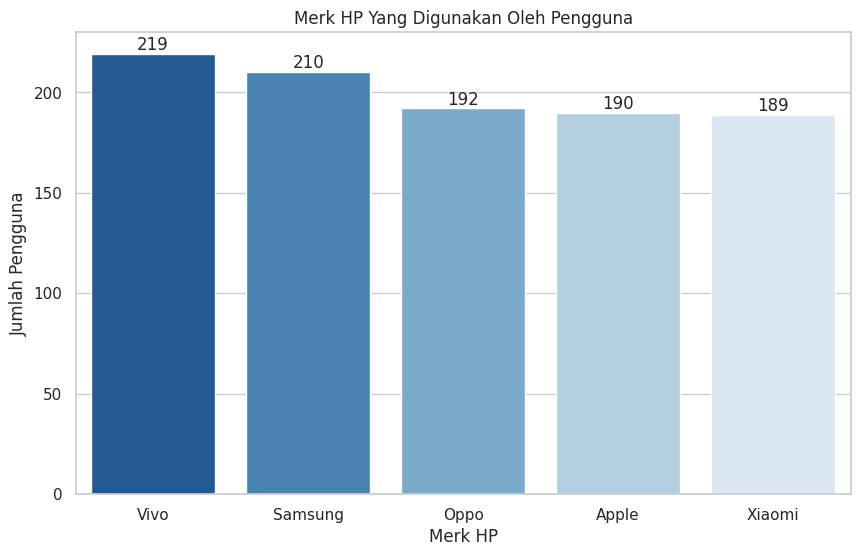

In [243]:
count_merk_hp = df['Merk HP'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=count_merk_hp.index, y=count_merk_hp, palette='Blues_r', hue=count_merk_hp.index, legend=False)
plt.xlabel('Merk HP')
plt.ylabel('Jumlah Pengguna')
plt.title('Merk HP Yang Digunakan Oleh Pengguna')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.bar_label(plt.gca().containers[3])
plt.bar_label(plt.gca().containers[4])
plt.show()

Berdasarkan hasil plot diatas, Vivo merupakan merk HP yang paling banyak digunakan oleh pengguna layanan dengan jumlah 219 pengguna, dilanjutkan dengan Samsung dengan 210 pengguna dan Oppo dengan 192 pengguna. Namun yang menjadi pertanyaan sekarang, melalui data kepemilikan merk HP ini, apakah kita sudah bisa menarik suatu kesimpulan untuk menjadi landasan analisis rekomendasi bisnis? Tentu saja belum !!!

## **Jumlah preferensi minat digital**

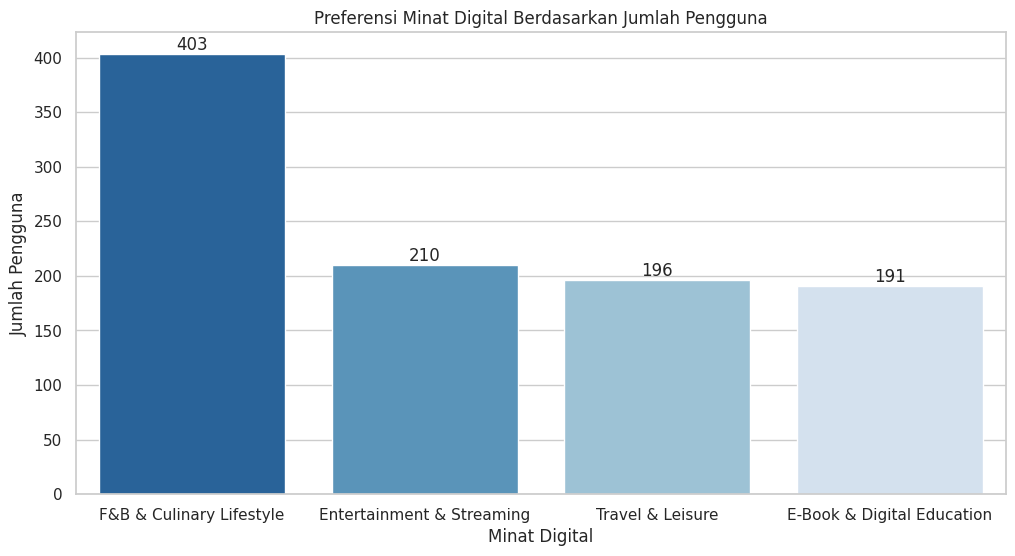

In [244]:
count_minat = df['Minat Digital'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=count_minat.index, y=count_minat, palette='Blues_r', hue=count_minat.index, legend=False)
plt.xlabel('Minat Digital')
plt.ylabel('Jumlah Pengguna')
plt.title('Preferensi Minat Digital Berdasarkan Jumlah Pengguna')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.bar_label(plt.gca().containers[3])
plt.show()

Bagaimana jika kita menambahkan data preferensi minat digital berdasarkan jumlah pengguna? Walaupun data ini memberikan informasi yang cukup signifikan pada analisis dengan memberikan informasi bahwa F&B & Culinary Lifestyle merupakan minat digital paling tinggi peminatnya dengan jumlah 403, diikuti oleh Entertainment  Streaming dengan 210, Travel & Leisure dengan 196 dan E-Book & Digital Education dengan 191. Kita masih belum bisa menyimpulkan suatu informasi dari kumpulan data ini.

## **Tipe lokasi terbanyak pengakses layanan**

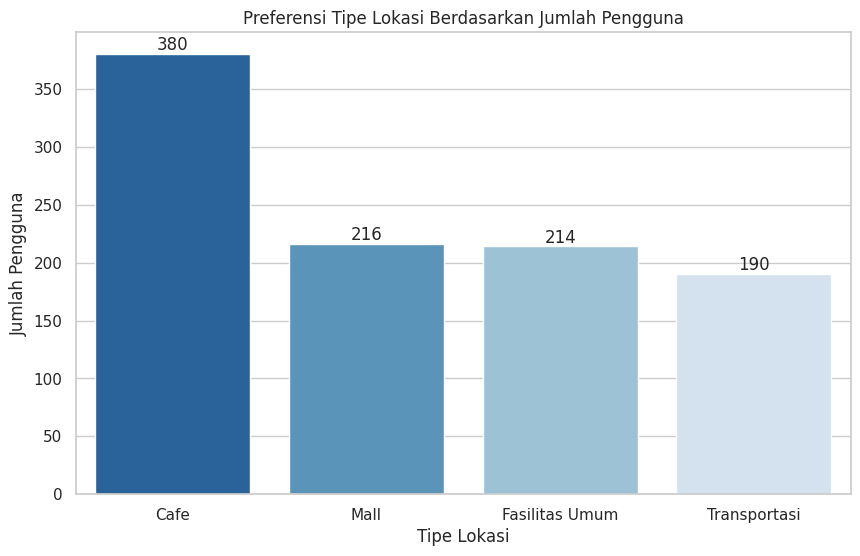

In [245]:
count_tipe_lokasi = df['Tipe Lokasi'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=count_tipe_lokasi.index, y=count_tipe_lokasi, palette='Blues_r', hue=count_tipe_lokasi.index, legend=False)
plt.xlabel('Tipe Lokasi')
plt.ylabel('Jumlah Pengguna')
plt.title('Preferensi Tipe Lokasi Berdasarkan Jumlah Pengguna')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.bar_label(plt.gca().containers[3])
plt.show()

Jika ditambahkan preferensi tipe lokasi berdasarkan jumlah pengguna? Jika digabungkan, dari data preferensi ini dan 2 data sebelumnya, kita bisa mendapatkan informasi yang berharga untuk menjadi rekomendasi bisnis nantinya.

Yang mana kita bisa mengetahui bahwa Cafe merupakan tipe lokasi yang paling banyak dikunjungi oleh pengguna layanan, sejalan dengan preferensi minat yang cenderung ke arah F&B & Culinary Lifestyle, yang mana Cafe merupakan tempat yang erat kaitannya dengan hal tersebut.

## **Lokasi terbanyak pengakses layanan**

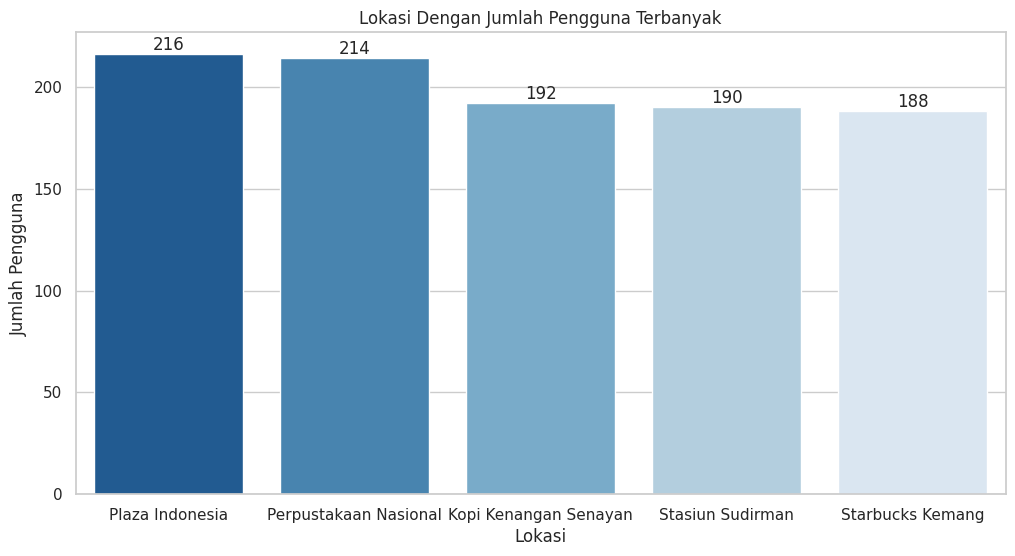

In [246]:
count_nama_lokasi = df['Nama Lokasi'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=count_nama_lokasi.index, y=count_nama_lokasi, palette='Blues_r', hue=count_nama_lokasi.index, legend=False)
plt.xlabel('Lokasi')
plt.ylabel('Jumlah Pengguna')
plt.title('Lokasi Dengan Jumlah Pengguna Terbanyak')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.bar_label(plt.gca().containers[3])
plt.bar_label(plt.gca().containers[4])
plt.show()

Namun, lokasi mana yang sebenarnya paling berkontribusi dalam penggunaan layanan bisnis? karena tidak mungkin kita melakukan suatu kegiatan atau promosi ke semua lokasi yang memiliki tipe lokasi yang sama.

Jika kita berpatokan pada chart diatas, kita dapat menemukan bahwa Plaza Indonesia merupakan lokasi yang paling banyak berkontribusi berdasarkan jumlah pengguna nya. Cukup menarik, mengingat Plaza Indonesia ini merupakan termasuk Mall dan bukan Cafe. Mengapa ini bisa terjadi?

Jika diperhatikan, data ini memiliki 2 jenis Cafe, yaitu Kopi Kenangan Senayan dan Starbucks Kemang, kedua Cafe tersebut jika digabungkan maka menghasilkan data tipe lokasi sebelumnya. Menarik bukan? Karena perbedaan jumlah dalam data bisa memberikan insight yang berbeda, jika tidak dilakukan analisis lebih mendalam, mungkin saja kita bisa memberikan rekomendasi yang salah.

Lalu bagaimana, apakah tetap dipilih kelopok tipe lokasi Cafe saja yang memiliki jumlah terbesar ketika diakumulasikan, atau memilih Plaza Indonesia sebagai lokasi dengan pengguna layanan terbanyak?

Jawabannya, kembali pada tujuan akhir dan budget.
Jika tujuan akhir ingin mempromosikan layanan bisnis dalam skala yang besar diberbeda tempat, maka Cafe bisa menjadi pilihan.

Namun jika yang diincar adalah pelaksanaan di 1 tempat namun tetap mencakup banyak pengguna, Plaza Indonesia bisa menjadi pilihan. Bagaimana dengan Perpustakaan Nasional? Jika memang ingin dimasukkan dan dibuat dalam skema seperti pada Cafe sebelumnya, Perpustakaan Nasional bisa menjadi pilihan, namun kekurangannya, dikarenakan Perpustakaan Nasional merupakan tempat masyarakat membaca buku dan membutuhkan situasi yang tenang, maka mungkin saja akan terdapat batasan-batasan tertentu dalam pelaksanaan nya.

## **Sebaran level minat digital pengguna**

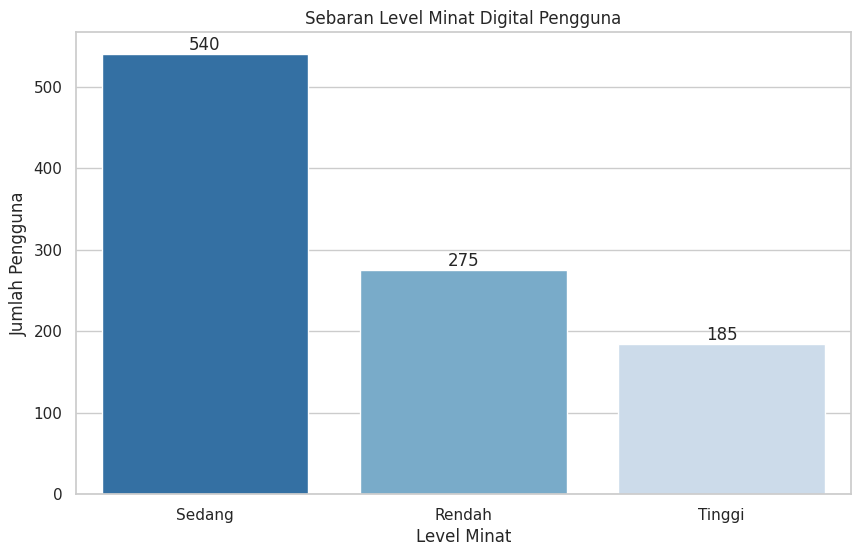

In [247]:
# Proporsi Level Minat Digital
level_minat_counts = df['Level Minat Digital'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=level_minat_counts.index, y=level_minat_counts, palette='Blues_r', hue=level_minat_counts.index, legend=False)
plt.xlabel('Level Minat')
plt.ylabel('Jumlah Pengguna')
plt.title('Sebaran Level Minat Digital Pengguna')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.show()

Sekarang kita sudah mengetahui potensi lokasi memungkinkan jika ingin dilakukan event promosi bisnis. Pertanyaan selanjutnya adalah, kelompok mana kah yang harus kita prioritaskan untuk menjadi target nya.

Jika kita memperhatikan chart diatas, kita bisa menemukan bahwa level minat digital pengguna masih dimayoritas oleh kelompok dengan level minat sedang dan rendah, yang artinya ada mungkin saja ada suatu hal yang menjadi kendala yang menahan para pengguna ini menjadi level yang lebih tinggi, seperti ketidakpuasan layanan, ketidaksesuaian layanan, dan sebagainya.

Untuk mempermudah dalam analisis dan mengelompokkan pengguna dan mencari root cause nya, mari kita kelompokkan pengguna menjadi 4 kelompok seperti yang dijabarkan dibawah ini.

## **Segmentasi pengguna**
1. Segmen **The Camper** (Durasi Tinggi, CTR Rendah): Pengguna yang nongkrong lama di kafe untuk belajar/bekerja, tetapi kebal terhadap iklan visual biasa.

2. Segmen **The Impulse Clicker** (Durasi Rendah, CTR Tinggi): Pengguna yang hanya sebentar terhubung WiFi (misal di stasiun/mal) tetapi sangat responsif mengeklik iklan.

3. Segmen **The Digital Star** (Durasi Tinggi, CTR Tinggi): Pengguna ideal dan paling bernilai tinggi bagi pengiklan karena aktif menggunakan internet sekaligus sering berinteraksi dengan kampanye iklan.

4. Segmen **The Passerby** (Durasi Rendah, CTR Rendah): Pengguna numpang lewat yang tidak memberikan banyak konversi nilai digital.

In [248]:
def tentukan_segmen(row):
  durasi_tinggi = row['Level Durasi Akses'] == 'Tinggi'
  ctr_tinggi = row['Level Respons CTR'] == 'Tinggi'

  if durasi_tinggi and not ctr_tinggi:
    return 'The Camper'
  elif not durasi_tinggi and ctr_tinggi:
    return 'The Impulse Clicker'
  elif durasi_tinggi and ctr_tinggi:
    return 'The Digital Star'
  else:
    return 'The Passerby'

# Menerapkan fungsi ke baris data untuk membuat kolom baru
df['Segmentasi Pengguna'] = df.apply(tentukan_segmen, axis=1)

### **Jumlah segmentasi pengguna**

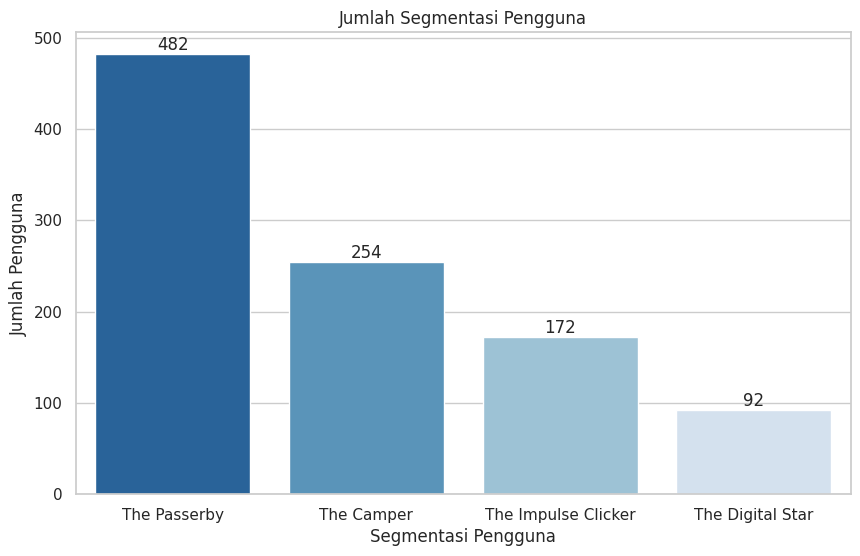

In [249]:
count_segmen = df['Segmentasi Pengguna'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=count_segmen.index, y=count_segmen, palette='Blues_r', hue=count_segmen.index, legend=False)
plt.xlabel('Segmentasi Pengguna')
plt.ylabel('Jumlah Pengguna')
plt.title('Jumlah Segmentasi Pengguna')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.bar_label(plt.gca().containers[2])
plt.bar_label(plt.gca().containers[3])
plt.show()

Jika didasarkan pada chart diatas, data masih didominasi oleh kelompok The Passerby, yang mana kelompok ini memiliki durasi mingguan yang rendah dan ctr yang rendah, sehingga bisa saja pengguna yang termasuk dalam kelompok ini memang pengguna yang hanya mampir di lokasi dan menggunakan layanan sebentar.

Yang menjadi masalah justru di kelompok The Camper, yang mana kelompok ini memiliki durasi mingguan yang tinggi namun CTR yang rendah, yang artinya pengguna yang termasuk kelompok ini merupakan pengguna yang sering datang ke lokasi, namun tidak begitu tertarik untuk mencari tau layanan bisnis lainnya.

Untuk 2 kelompok lainnya yaitu The Impulse Clicker dan The Digital Star, sementara bisa dibiarkan dulu saja namun tetap bisa dioptimalkan dalam rangka mempromosikan layanan bisnis lainnya pada non pelanggan maupun kelompok sebelumnya.

### **Persebaran segmentasi pengguna**

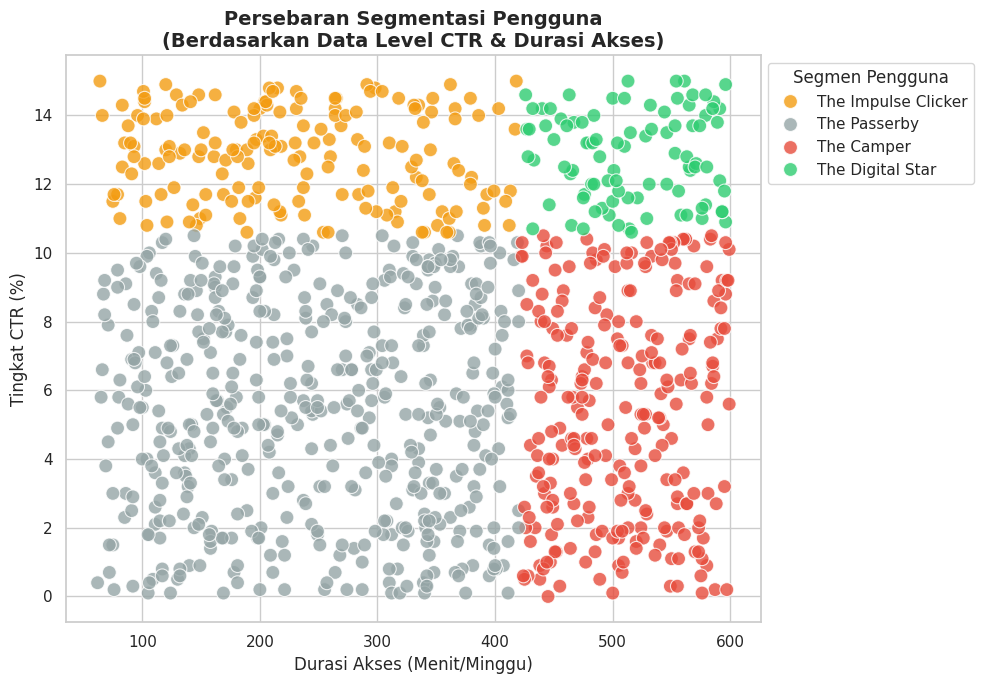

In [250]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Durasi Akses (Menit/Minggu)',
    y='CTR',
    hue='Segmentasi Pengguna',
    palette={'The Camper': '#e74c3c', 'The Impulse Clicker': '#f39c12',
             'The Digital Star': '#2ecc71', 'The Passerby': '#95a5a6'},
    s=100, alpha=0.8
)

plt.title('Persebaran Segmentasi Pengguna\n(Berdasarkan Data Level CTR & Durasi Akses)', fontsize=14, fontweight='bold')
plt.xlabel('Durasi Akses (Menit/Minggu)')
plt.ylabel('Tingkat CTR (%)')
plt.legend(title='Segmen Pengguna', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Persebaran segmentasi berdasarkan tipe lokasi**

<Figure size 1200x1200 with 0 Axes>

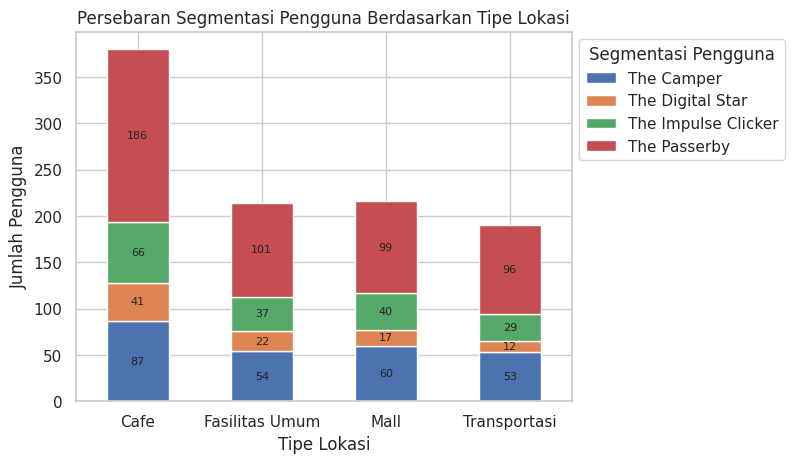

In [251]:
lokasi_segmen = pd.crosstab(df['Tipe Lokasi'], df['Segmentasi Pengguna'])

plt.figure(figsize=(12, 12))
ax = lokasi_segmen.plot(kind='bar', stacked=True)
plt.title('Persebaran Segmentasi Pengguna Berdasarkan Tipe Lokasi')
plt.xlabel('Tipe Lokasi')
plt.ylabel('Jumlah Pengguna')
plt.legend(title='Segmentasi Pengguna', bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, label_type='center', fontsize=8)
plt.show()

## **Persebaran segmentasi berdasarkan nama lokasi**

<Figure size 1200x1200 with 0 Axes>

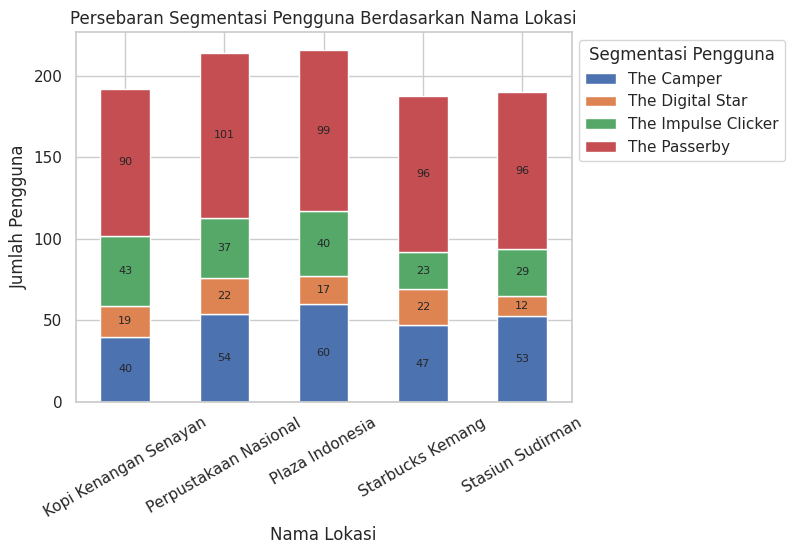

In [252]:
nama_lokasi_segmen = pd.crosstab(df['Nama Lokasi'], df['Segmentasi Pengguna'])

plt.figure(figsize=(12, 12))
ax = nama_lokasi_segmen.plot(kind='bar', stacked=True)
plt.title('Persebaran Segmentasi Pengguna Berdasarkan Nama Lokasi')
plt.xlabel('Nama Lokasi')
plt.ylabel('Jumlah Pengguna')
plt.legend(title='Segmentasi Pengguna', bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks(rotation=30)
for c in ax.containers:
  ax.bar_label(c, label_type='center', fontsize=8)
plt.show()

Sama seperti sebelumnya, untuk mengoptimalkan upaya promosi dan perbaikan kualitas layanan bisnis, kita perlu mengetahui berapa proporsi masing-masing kelompok dari setiap tempat.

Berdasarkan chart diatas, Plaza Indonesia sebagai tempat dengan pengguna terbanyak memiliki kelompok The Camper terbanyak, namun jika dibandingkan dengan kelompok lainnya seperti The Digital Star dan The Impulse Clicker, kelompok ini masih kalah jumlah dibandingkan dengan beberapa lokasi lainnya.

Tentu ini menjadi masalah, lokasi yang seharusnya menjadi tempat promosi dan pendapatan terbesar justru malah berpotensi menjadi lokasi dengan jumlah pendapatan dan promosi yang lebih kecil dibandingkan beberapa tempat lainnya.

In [257]:
ringkasan_usia = df.groupby('Segmentasi Pengguna')['Usia'].describe()
ringkasan_usia

,count,mean,std,min,25%,50%,75%,max
Segmentasi Pengguna,,,,,,,,
The Camper,254.0,31.480315,8.749343,18.0,23.0,31.0,39.00,46.0
The Digital Star,92.0,31.195652,8.552667,18.0,25.0,29.0,38.25,46.0
The Impulse Clicker,172.0,30.895349,8.032870,18.0,24.0,30.0,39.00,46.0
The Passerby,482.0,31.804979,8.460212,18.0,24.0,32.0,40.00,46.0


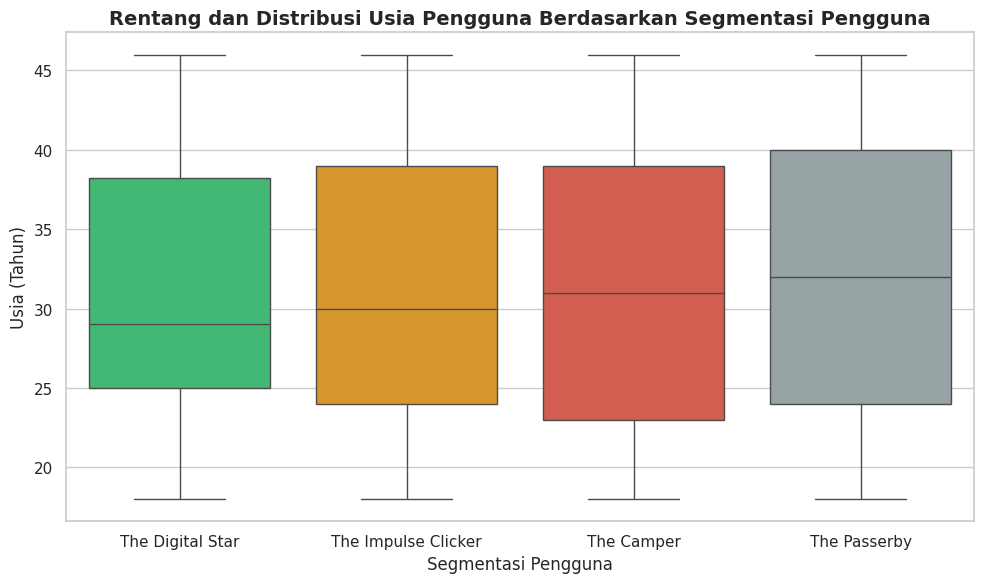

In [258]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Segmentasi Pengguna',
    y='Usia',
    hue='Segmentasi Pengguna',
    palette={'The Camper': '#e74c3c', 'The Impulse Clicker': '#f39c12',
             'The Digital Star': '#2ecc71', 'The Passerby': '#95a5a6'},
    order=['The Digital Star', 'The Impulse Clicker', 'The Camper', 'The Passerby'],
    legend=False
)

plt.title('Rentang dan Distribusi Usia Pengguna Berdasarkan Segmentasi Pengguna', fontsize=14, fontweight='bold')
plt.xlabel('Segmentasi Pengguna', fontsize=12)
plt.ylabel('Usia (Tahun)', fontsize=12)
plt.tight_layout()
plt.show()

Lalu bagaimana solusinya? Untuk menyelesaikan permasalahan tersebut, cara paling mudah adalah kita perlu mengetahui dahulu karakteristik dari masing-masing kelompok, seperti contoh pada boxplot diatas.

Berdasarkan boxplot diatas, ditemukan bahwa rata-rata umur kelompok The Camper terdapat pada range 31-32 tahun dengan nilai minimal umur nya adalah 18 tahun dan maksimal umur nya adalah 46 tahun. Namun jika diperhatikan, keseluruhan kelompok memiliki minimal umur dan maksimal umur yang sama, sehingga data minimal dan maksimal umur tersebut tidak dapat digunakan. Sehingga untuk data tambahan, data yang dapat digunakan adalah data kuartil.

Jika diperhatikan melalui data kuartil, The Camper memiliki pembagian data 23 pada kuartil 1 (25%), 31 pada kuartil 2 (50%) dan 39 pada kuartil 3 (75%). Nilai ini mengintrepretasikan 25% data memiliki rentang sama atau lebih rendah dari 23 tahun (18-23), yang mana nilai ini lebih rendah dibandingkan kelompok lain, dan memiliki nilai 25% diatas 39 tahun (40-46), yang mana nilai ini serupa dengan kelompok The Impulse Clicker dan lebih rendah dibandingkan kelompok The Passerby.

# **Interpretasi solusi**

In [254]:
df.head(5)

,Nama Lokasi,Tipe Lokasi,Merk HP,Minat Digital,CTR,Durasi Akses (Menit/Minggu),Skor CTR,Skor Durasi Akses (Menit/Minggu),Skor Minat Digital,Level Respons CTR,Level Durasi Akses,Level Minat Digital,Usia,Sesi Login,Segmentasi Pengguna
0,Kopi Kenangan Senayan,Cafe,Apple,F&B & Culinary Lifestyle,11.0,149,73.333333,24.833333,49.1,Tinggi,Rendah,Sedang,39,Malam,The Impulse Clicker
1,Stasiun Sudirman,Transportasi,Apple,F&B & Culinary Lifestyle,7.6,87,50.666667,14.500000,32.6,Sedang,Rendah,Rendah,44,Siang,The Passerby
2,Stasiun Sudirman,Transportasi,Vivo,Entertainment & Streaming,3.3,344,22.000000,57.333333,39.7,Rendah,Sedang,Rendah,24,Pagi,The Passerby
3,Kopi Kenangan Senayan,Cafe,Xiaomi,F&B & Culinary Lifestyle,3.2,404,21.333333,67.333333,44.3,Rendah,Sedang,Sedang,36,Pagi,The Passerby
4,Kopi Kenangan Senayan,Cafe,Xiaomi,Travel & Leisure,4.0,104,26.666667,17.333333,22.0,Rendah,Rendah,Rendah,35,Malam,The Passerby
